# BOSQUE Dataset • Exploratory Data Analysis
This notebook performs a descriptive exploration of the anonymised BOSQUE metadata before modeling malignant‑lesion prediction.
It includes:
1. Target variable creation
2. Distribution plots
3. Stratified breakdowns
4. Basic statistical associations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import scipy.stats as ss
import os

# Get current notebook directory
script_dir = Path(os.getcwd())

# Go up one level and into data folder
csv_path = script_dir.parent / "data" / "BOSQUE_metadata.csv"

df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")
df.head()

Loaded 165 rows and 14 columns


,file_name,patient_id,sex,skin_phototype,age_group,anatomical_site,evolution_bucket,size_bucket,hx_nmsc,photosens_drugs,lesion_nature,diagnosis_method,clinical_label,histology_label
0,BOSQUE_100141,141,female,IV,85–89,head_neck,1y,11-20mm,no,yes,malignant,histopathological,non-melanocytic,akiec
1,BOSQUE_100231,231,male,III,85–89,trunk_anterior,2y,11-20mm,no,yes,malignant,histopathological,non-melanocytic,akiec
2,BOSQUE_100232,232,male,III,85–89,head_neck,1y,11-20mm,no,yes,malignant,histopathological,non-melanocytic,akiec
3,BOSQUE_300321,321,male,II,65–69,head_neck,3–4y,6-10mm,no,no,malignant,histopathological,non-melanocytic,bkl
4,BOSQUE_100431,431,female,III,75–79,head_neck,2y,6-10mm,no,no,malignant,histopathological,non-melanocytic,akiec


In [2]:
malignant_set = {'mel', 'bcc', 'akiec'}
df['malignant'] = df['histology_label'].isin(malignant_set).astype(int)
df['malignant'].value_counts()

malignant
1    98
0    67
Name: count, dtype: int64

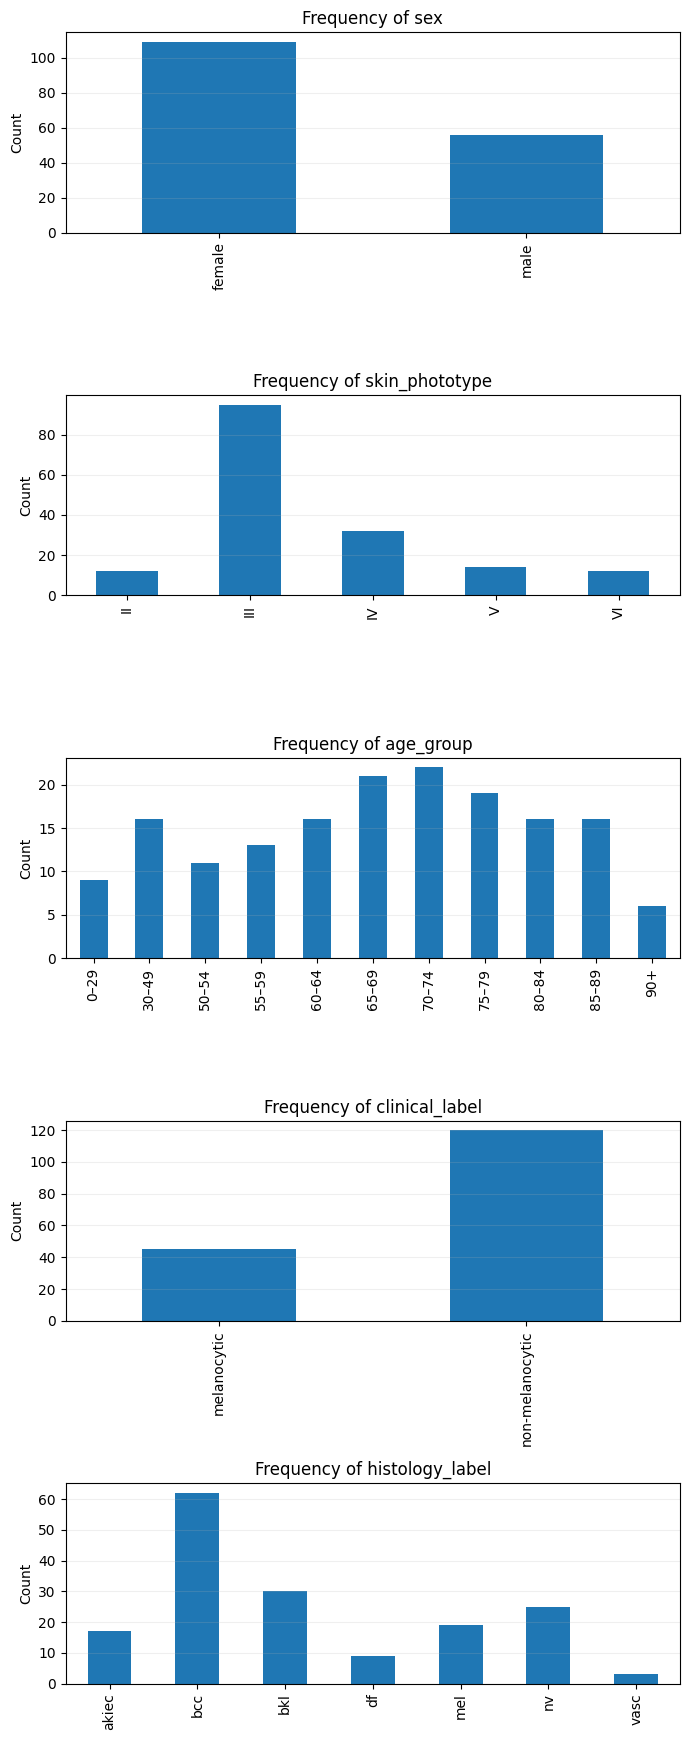

In [3]:
# -----------------------------------------------------------
# Frequency plots for all key categorical variables
# -----------------------------------------------------------
# Pick the variables you want to visualise
cat_vars = ['sex',
            'skin_phototype',
            'age_group',
            'clinical_label',
            'histology_label']

# ------------------------------------------------------------------
# Figure 1  Raw counts
# ------------------------------------------------------------------
n = len(cat_vars)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(7, 3.5 * n))

for ax, var in zip(axes, cat_vars):
    (df[var]
     .value_counts()
     .sort_index()
     .plot(kind='bar', ax=ax))
    
    ax.set_title(f'Frequency of {var}')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()


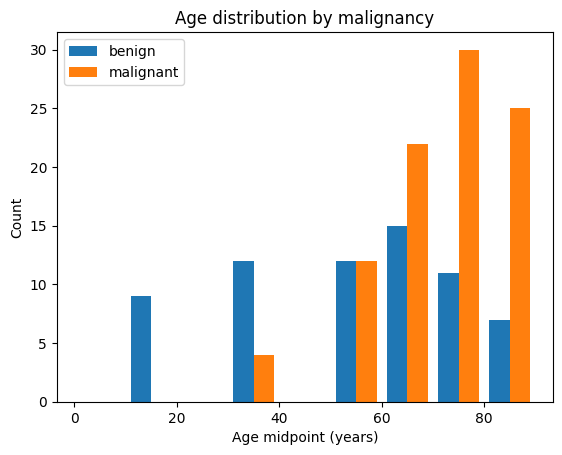

In [6]:
import re

def midpoint(age_grp: str) -> float:
    """
    Convert an age-group label (e.g. '30–49', '50-54', '90+') → midpoint.
    Returns NaN if the string cannot be parsed.
    """
    if pd.isna(age_grp):
        return float("nan")

    s = str(age_grp).strip()

    # Normalise en-dash / em-dash to a simple hyphen
    s = re.sub(r"[–—]", "-", s)

    # Handle top-coded group like '90+'
    if s.endswith("+"):
        start = int(s[:-1])
        # assume 5-year width for 90+  → midpoint 92.5
        end = start + 4
        return (start + end) / 2

    # Standard range 'start-end'
    try:
        start, end = map(int, s.split("-"))
        return (start + end) / 2
    except ValueError:
        # unparsable label
        return float("nan")

# ---------------- apply to dataframe ---------------------------------------
df["age_mid"] = df["age_group"].astype(str).apply(midpoint)

# ---------------- plot by malignancy ---------------------------------------
plt.hist(
    [df[df.malignant == 0]["age_mid"], df[df.malignant == 1]["age_mid"]],
    bins=range(0, 100, 10),
    label=["benign", "malignant"],
)
plt.legend()
plt.xlabel("Age midpoint (years)")
plt.ylabel("Count")
plt.title("Age distribution by malignancy")
plt.show()

In [7]:
for var in ['sex', 'skin_phototype', 'clinical_label', 'histology_label']:
    tbl = pd.crosstab(df[var], df['malignant'])
    chi2, p, *_ = ss.chi2_contingency(tbl)
    print(f"{var:<20} p = {p:.4f}")

sex                  p = 0.3554
skin_phototype       p = 0.0000
clinical_label       p = 0.0034
histology_label      p = 0.0000


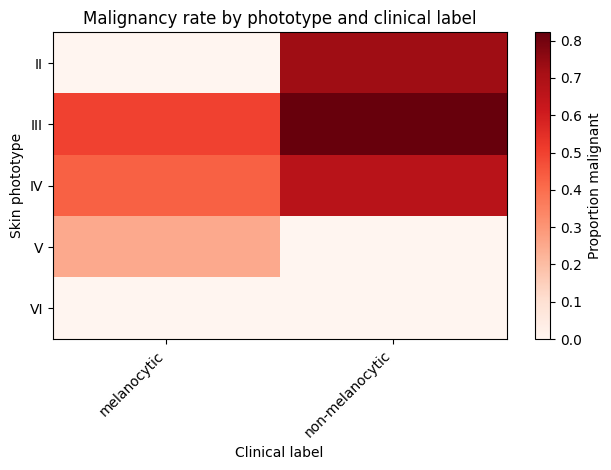

In [8]:
# Pivot benign/malignant proportions for a heat-map
pivot = (
    pd.crosstab(df['skin_phototype'], df['clinical_label'],
                values=df['malignant'], aggfunc='mean')
    .sort_index()
)

plt.imshow(pivot, aspect='auto', cmap='Reds')
plt.colorbar(label='Proportion malignant')
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha='right')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title('Malignancy rate by phototype and clinical label')
plt.xlabel('Clinical label')
plt.ylabel('Skin phototype')
plt.tight_layout()
plt.show()


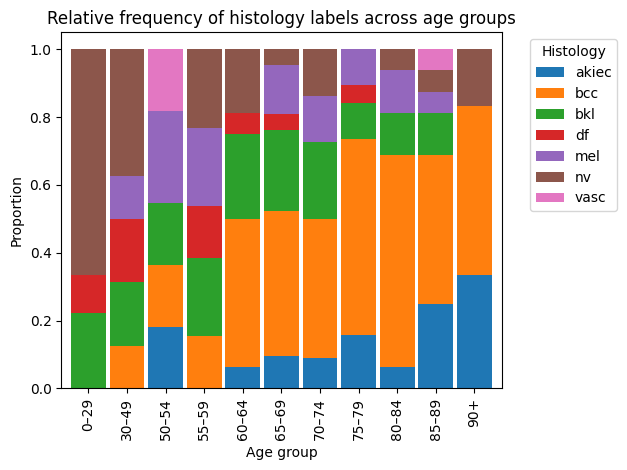

In [9]:
age_hist = pd.crosstab(df['age_group'], df['histology_label'], normalize='index')
age_hist.plot(kind='bar', stacked=True, width=0.9)
plt.legend(title='Histology', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Relative frequency of histology labels across age groups')
plt.ylabel('Proportion')
plt.xlabel('Age group')
plt.tight_layout()
plt.show()


C:\Users\amorales\AppData\Local\Temp\ipykernel_16760\2457904160.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


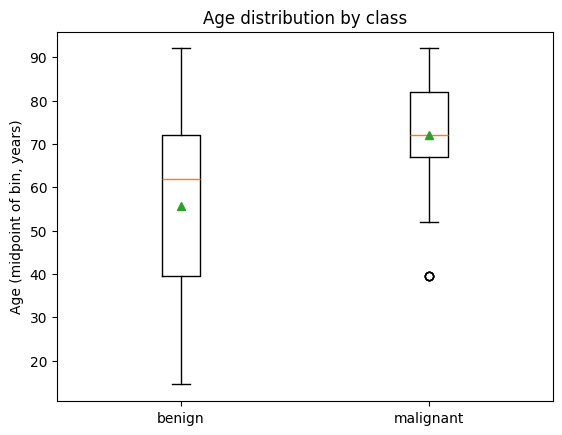

In [11]:
# Convert age_group to numeric midpoint 
if "age_mid" not in df.columns:
    def midpoint(label: str) -> float:
        """Return the midpoint of an age-group label."""
        if pd.isna(label):
            return float("nan")

        s = str(label).strip()
        s = re.sub(r"[–—]", "-", s)          # normalise en/em dash to hyphen

        if s.endswith("+"):                  # e.g. '90+'
            start = int(s[:-1])
            end   = start + 4                # assume 5-year width
            return (start + end) / 2         # 92.5 for 90+

        try:
            lo, hi = map(int, s.split("-"))
            return (lo + hi) / 2
        except ValueError:
            return float("nan")              # unparsable → NaN

    df["age_mid"] = df["age_group"].apply(midpoint)

# ---------------------------------------------------------------------------
# 2.  Boxplot: benign vs malignant
# ---------------------------------------------------------------------------
benign_ages     = df.loc[df.malignant == 0, "age_mid"].dropna()
malignant_ages  = df.loc[df.malignant == 1, "age_mid"].dropna()

plt.boxplot(
    [benign_ages, malignant_ages],
    labels=["benign", "malignant"],
    showmeans=True,
)
plt.ylabel("Age (midpoint of bin, years)")
plt.title("Age distribution by class")
plt.show()


## Cramér’s V Analysis – Association with Malignancy

In [12]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(var1, var2):
    ctab = pd.crosstab(var1, var2)
    chi2, _, _, _ = chi2_contingency(ctab)
    n = ctab.sum().sum()
    k = min(ctab.shape)-1
    return np.sqrt(chi2 / (n * k))

cat_vars = ['sex', 'skin_phototype', 'clinical_label', 'histology_label']
cramers = pd.Series({v: cramers_v(df[v], df['malignant']) for v in cat_vars})
cramers.sort_values(ascending=False).to_frame('Cramérs V')


,Cramérs V
histology_label,1.000000
skin_phototype,0.510897
clinical_label,0.227978
sex,0.071950


## Light (I–III) vs Dark (IV–VI) phototype analysis

In [13]:
import pandas as pd, matplotlib.pyplot as plt, scipy.stats as ss

# 1. Map phototypes to light / dark
light_set = {'I', 'II', 'III'}
df['phototype_group'] = df['skin_phototype'].apply(
    lambda x: 'light' if str(x).strip() in light_set else 'dark'
)

# 2. Binary malignant flag (edit list if your definition differs)
malignant_set = {'mel', 'bcc', 'akiec'}
df['malignant'] = df['histology_label'].isin(malignant_set)

# 3. Contingency table and χ²
cont = pd.crosstab(df['phototype_group'], df['malignant'])
chi2, p, dof, exp = ss.chi2_contingency(cont)


# Build pretty summary
summary = pd.DataFrame({
    'Benign (n)':    cont[False],
    'Malignant (n)': cont[True],
})
summary['Malignancy rate'] = (summary['Malignant (n)'] /
                              summary.sum(axis=1)).mul(100).round(1).astype(str) + ' %'

display(summary)



print("Chi-square =", chi2, "| p-value =", p)


,Benign (n),Malignant (n),Malignancy rate
phototype_group,,,
dark,39,19,32.8 %
light,28,79,73.8 %


Chi-square = 24.633920423908588 | p-value = 6.932074329787731e-07


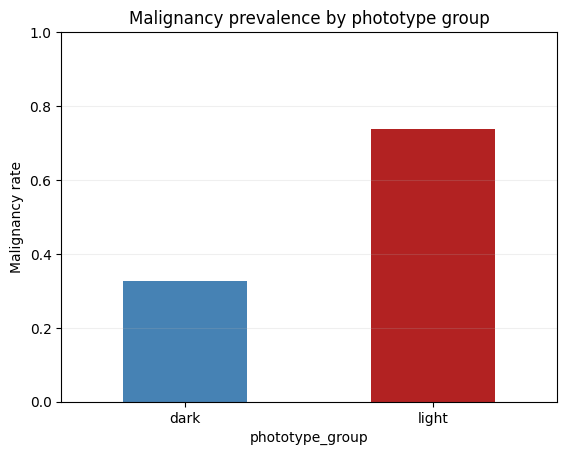

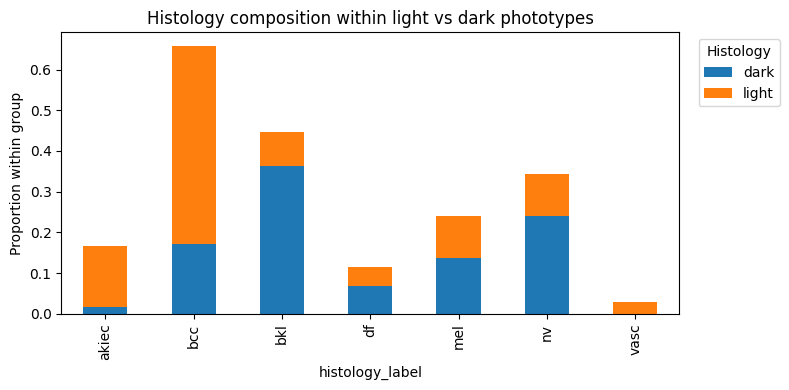

In [14]:

# 4. Malignancy rate bar plot
rates = cont.div(cont.sum(axis=1), axis=0)[True]
rates.plot(kind='bar', color=['steelblue', 'firebrick'], rot=0)
plt.ylabel('Malignancy rate')
plt.title('Malignancy prevalence by phototype group')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.2)
plt.show()

# 5. Stacked histology distribution
hist_dist = pd.crosstab(df['phototype_group'], df['histology_label'],
                        normalize='index')
hist_dist.T.plot(kind='bar', stacked=True, figsize=(8,4))
plt.title('Histology composition within light vs dark phototypes')
plt.ylabel('Proportion within group')
plt.legend(title='Histology', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()